# Anatomía del pipeline GNN-HVA — TFIM 1D, N=10

Notebook **educativo y modular**: recorre cada fase del flujo GNN-HVA mostrando
*qué es* cada objeto (grafo del lattice, Hamiltoniano, ansatz HVA, circuito
llenado, circuito transpilado, grafo del MPNN, θ predichos) con salida en **PNG**
cuando es posible y **texto** cuando conviene.

Reutiliza los módulos de producción (`qmbp_simulation`) — no reimplementa nada.
Puntos clave de esta versión:

- **Ansatz bond-resolved** (`create_bond_resolved`): un θ_zz por bond + un θ_x por
  sitio. Es el ansatz que usan los modelos entrenados del zoo. Para chain N=10 p=1
  son **19 parámetros** (9 bonds + 10 sitios).
- **Auto-selección del zoo**: en vez de entrenar, `select_model_for_objective`
  elige el mejor modelo pre-entrenado para el objetivo, con un reporte de
  confianza y warnings (transparente sobre cuánto confiar).
- **Fase transpilada**: el circuito llevado a gates nativos de hardware, con
  conteo de compuertas de 2 qubits y profundidad (lógico vs nativo).

### El hilo conductor: una misma cadena atraviesa todas las fases

El notebook no son fases sueltas — es **un solo objeto visto desde ángulos
distintos**. Cada término del Hamiltoniano se propaga, sin cambiar de identidad,
a través de todo el pipeline:

| Término de $H$ (fase 2) | → Compuerta del ansatz (fase 3) | → Nodo del grafo (fase 7) | → Parámetro predicho (fase 8) |
|---|---|---|---|
| $-J\,Z_iZ_j$ (por bond) | $R_{ZZ}(2\theta_{zz})$ en ese bond | nodo **ZZ-gate** | $\theta_{zz}^{(k)}$ |
| $-h\,X_i$ (por sitio) | $R_X(2\theta_x)$ en ese qubit | nodo **qubit** | $\theta_x^{(i)}$ |

Y esa cadena **se cierra** en la energía: el VQE (fase 5) y el GNN (fases 6-9)
buscan los $\theta$ que hacen $\langle\psi(\theta)|H|\psi(\theta)\rangle$ lo más
cercano posible al $E_0$ exacto (fase 4). Cuando en una fase digamos "esto viene
de" o "esto reaparece en", nos referimos a esta cadena. Seguirla es entender el
pipeline completo.

| Fase | Módulo reutilizado |
|------|--------------------|
| Lattice / grafo | `HamiltonianBuilder.build_graph_data`, helper `draw_lattice_graph` |
| Hamiltoniano | `HamiltonianBuilder.build`, `make_lattice` |
| Ansatz HVA (bond-resolved) | `HVACircuitBuilder.create_bond_resolved` |
| Render / stats de circuitos | `analysis.circuit_visualizer` |
| Transpilación | `qiskit.transpile` + `transpiled_circuit_stats` |
| Ground truth | `ClassicalSolver.solve` |
| VQE | `VQEOptimizer`, `VQEConfig` |
| Auto-selección GNN | `model_zoo.select_model_for_objective` |
| Grafo del GNN | `unified_graph.build_graph_for_model` |

> Corre 100% en simulación local. No requiere credenciales ni hardware.


## 0. Setup — configuración única e intercambiable

Editá `PipelineConfig` para explorar otros regímenes.

In [1]:
# Make the notebook helpers importable regardless of CWD
import sys, os
from pathlib import Path
_NB_DIR = Path.cwd() if (Path.cwd() / "pipeline_anatomy_helpers.py").exists() else Path.cwd() / "notebooks" / "gnn_hva_pipeline_anatomy"
if str(_NB_DIR) not in sys.path:
    sys.path.insert(0, str(_NB_DIR))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from pipeline_anatomy_helpers import (
    PipelineConfig,
    draw_lattice_graph,
    draw_mpnn_graph,
    save_line_plot,
    save_matrix_heatmap,
)

cfg = PipelineConfig()          # <-- edit fields here to explore
FIG = cfg.figures_dir
print("Config:")
for k, v in vars(cfg).items():
    print(f"  {k:16s} = {v}")

def show(path):
    """Display a saved PNG inline (path may be Path or None)."""
    if path and Path(path).exists():
        display(Image(filename=str(path)))
    else:
        print("[no image]")

Config:
  topology         = chain_1d
  n_qubits         = 10
  p_layers         = 1
  j_coupling       = 1.0
  h_values         = (0.5, 1.0, 1.5, 2.0, 2.5)
  h_focus          = 1.0
  vqe_maxiter      = 300
  vqe_restarts     = 1
  seed             = 42
  zoo_model        = tfim_bond_resolved
  zoo_objective    = critical
  basis_gates      = ('cz', 'rz', 'sx', 'x')
  opt_level        = 3
  figures_dir      = /Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatomy/figures


## 1. El lattice (grafo físico)

El primer objeto es la **topología**: qué qubits interactúan. `make_lattice`
devuelve un `LatticeConfig` con la lista de aristas (bonds) y los números de
coordinación. Ese mismo grafo es el que después alimenta al MPNN.


topology         : chain_1d
n_qubits         : 10
edges (bonds)    : 9  ->  [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9)]
coordination     : [1, 2, 2, 2, 2, 2, 2, 2, 2, 1]
bond-resolved θ  : 9 (θ_zz per bond) + 10 (θ_x per site) = 19


/Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatomy/pipeline_anatomy_helpers.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


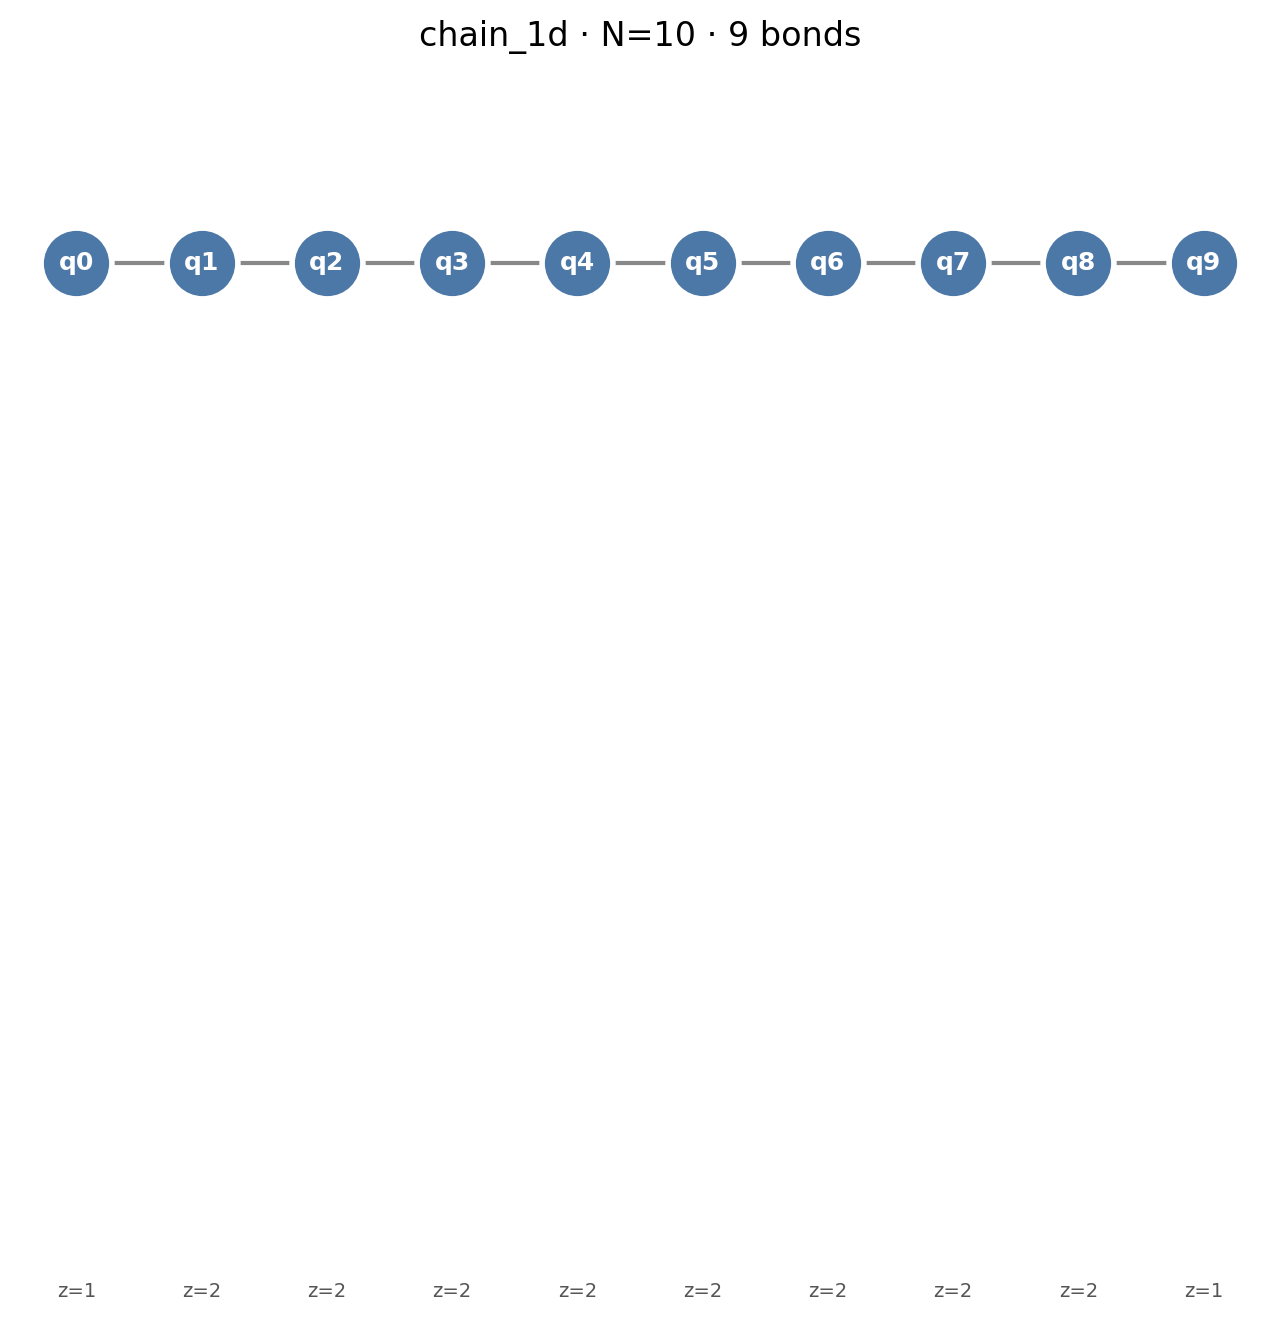

In [2]:
from qmbp_simulation.models import make_lattice, HamiltonianBuilder

lattice = make_lattice(cfg.topology, cfg.n_qubits, J=cfg.j_coupling, h=cfg.h_focus)
builder = HamiltonianBuilder()
edge_index, coord = builder.build_graph_data(lattice)
n_edges = len(lattice.edges)
n_params = cfg.n_params_bond_resolved(n_edges)   # bond-resolved param count

print(f"topology         : {lattice.topology}")
print(f"n_qubits         : {lattice.n_qubits}")
print(f"edges (bonds)    : {n_edges}  ->  {lattice.edges}")
print(f"coordination     : {coord.tolist()}")
print(f"bond-resolved θ  : {n_edges} (θ_zz per bond) + {cfg.n_qubits} (θ_x per site) = {n_params}")

p = draw_lattice_graph(lattice, FIG / "01_lattice.png",
                       title=f"{cfg.topology} · N={cfg.n_qubits} · {n_edges} bonds")
show(p)

## 2. El Hamiltoniano TFIM

$$H = -J\sum_{\langle i,j\rangle} Z_i Z_j \; -\; h\sum_i X_i$$

`HamiltonianBuilder.build(lattice)` lo devuelve como `SparsePauliOp`. Mostramos
los términos de Pauli (texto) y, como N=10 es chico, un heatmap de la matriz
densa para *ver* su estructura dispersa (PNG).


H.num_qubits = 10
n Pauli terms = 19

First Pauli terms (label : coeff):
  IIIIIIIIZZ : -1.000
  IIIIIIIZZI : -1.000
  IIIIIIZZII : -1.000
  IIIIIZZIII : -1.000
  IIIIZZIIII : -1.000
  IIIZZIIIII : -1.000
  IIZZIIIIII : -1.000
  IZZIIIIIII : -1.000
  ZZIIIIIIII : -1.000
  IIIIIIIIIX : -1.000
  IIIIIIIIXI : -1.000
  IIIIIIIXII : -1.000


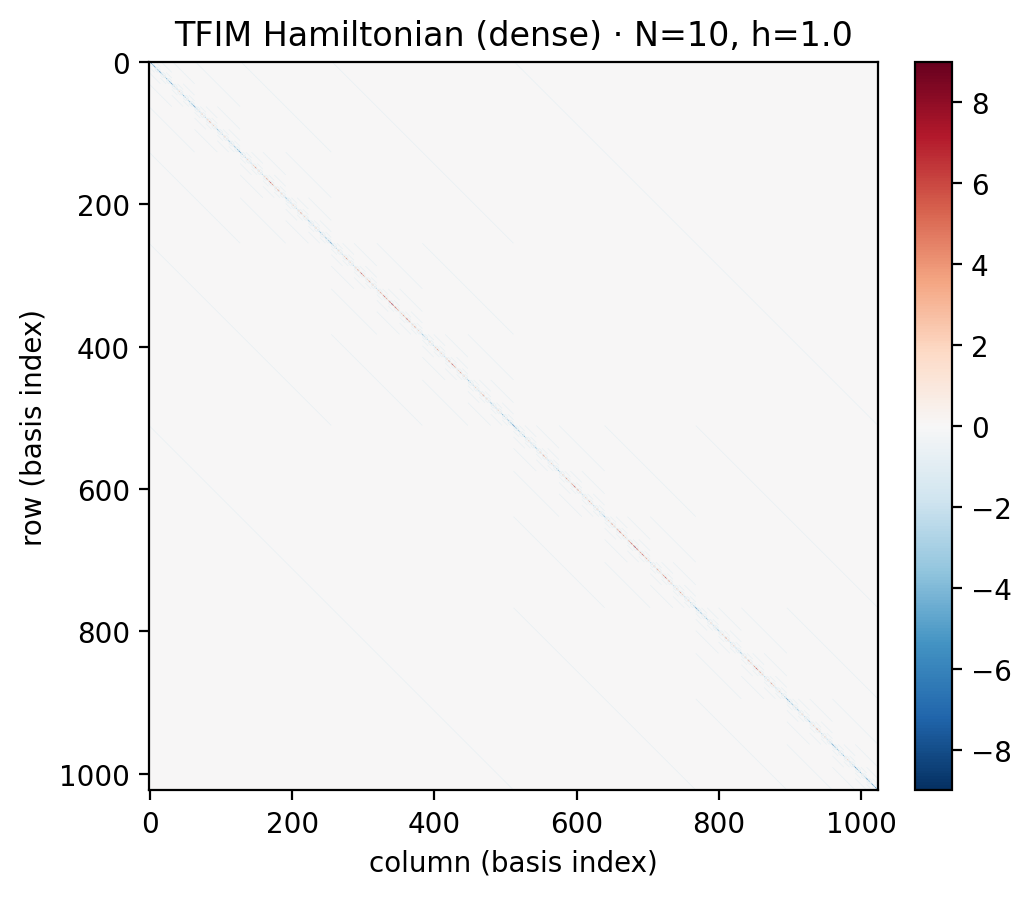


matrix shape = (1024, 1024)  (2^N x 2^N)


In [3]:
H = builder.build(lattice)
print(f"H.num_qubits = {H.num_qubits}")
print(f"n Pauli terms = {len(H)}")
print("\nFirst Pauli terms (label : coeff):")
for label, coeff in list(zip(H.paulis.to_labels(), H.coeffs))[:12]:
    print(f"  {label} : {coeff.real:+.3f}")

mat = np.real(H.to_matrix())
p = save_matrix_heatmap(mat, FIG / "02_hamiltonian_matrix.png",
                        title=f"TFIM Hamiltonian (dense) · N={cfg.n_qubits}, h={cfg.h_focus}")
show(p)
print(f"\nmatrix shape = {mat.shape}  (2^N x 2^N)")

## 3. El ansatz HVA bond-resolved (parametrizado, sin llenar)

Esta es la pieza central: el **circuito variacional** cuyos parámetros vamos a
optimizar para que su estado de salida aproxime el ground state de $H$.

### Cómo se construye, compuerta por compuerta

**Paso 0 — Estado inicial $|+\rangle^{\otimes N}$.** El circuito empieza con una
Hadamard en cada qubit. Esto no es arbitrario: $|+\rangle^{\otimes N}$ es
*exactamente* el ground state del término de campo transverso $-h\sum_i X_i$
(cada $|+\rangle$ es autovector de $X$ con autovalor $+1$). Es decir, arrancamos
en la solución exacta del límite $h\to\infty$ (fase paramagnética pura) y las
capas siguientes "encienden" el acoplamiento $ZZ$.

**Paso 1..p — Capas HVA.** El *Hamiltonian Variational Ansatz* alterna dos
evoluciones, una por cada término de $H = -J\sum ZZ - h\sum X$:

$$|\psi(\theta)\rangle = \prod_{\ell=1}^{p}
   \Big[\underbrace{e^{-i\theta_x^{(\ell)} H_X}}_{\text{campo transverso}}\;
        \underbrace{e^{-i\theta_{zz}^{(\ell)} H_{ZZ}}}_{\text{acoplamiento}}\Big]\;
   |+\rangle^{\otimes N}$$

**Por qué esta forma:** imita un paso de **Trotter** de la evolución bajo $H$
(o un paso de evolución adiabática desde el límite paramagnético hacia el
acoplado). Cada capa acerca el estado un poco más al ground state real; con más
capas $p$, la aproximación mejora. Los ángulos $\theta$ son los "tiempos" de cada
evolución, y son lo que optimizamos.

### Convención de compuertas (importante para leer el diagrama)

Qiskit implementa las evoluciones con:

- $R_{ZZ}(2\theta_{zz}) = e^{-i\theta_{zz}\,Z_iZ_j}$ sobre cada bond $(i,j)$ — el
  factor 2 hace que el ángulo de la compuerta corresponda a $e^{-i\theta ZZ}$.
- $R_X(2\theta_x) = e^{-i\theta_x X_i}$ sobre cada sitio $i$.

Así, una capa HVA = "un $R_{ZZ}$ en cada arista del lattice, seguido de un $R_X$
en cada qubit".

### Por qué *bond-resolved*

El HVA estándar usa **un solo** $\theta_{zz}$ para todos los bonds y **un solo**
$\theta_x$ para todos los sitios (2 parámetros por capa). La variante
**bond-resolved** le da a **cada bond su propio $\theta_{zz}^{(k)}$** y a **cada
sitio su propio $\theta_x^{(i)}$**. Para chain N=10 p=1: $9+10=19$ parámetros.

Esto **no agrega ni una compuerta** (mismo circuito, mismos $R_{ZZ}$/$R_X$) — solo
rompe la simetría de compartir ángulos. La ganancia: puede representar estados
donde los bonds no son equivalentes (p. ej. cerca de bordes, o estados con
simetría rota), lo que lo hace más expresivo y, a la vez, un espacio de búsqueda
más rico donde un predictor como el GNN se vuelve realmente útil. Es el ansatz
que esperan los modelos del zoo (`tfim_bond_resolved`).

En el diagrama de abajo verás: una columna de $H$ (Hadamards) al inicio, luego los
$R_{ZZ}$ (compuertas de 2 qubits, una por bond) y finalmente los $R_X$ (una por
qubit). Los parámetros aparecen simbólicos porque aún no los llenamos.

### Hacia adelante: cada compuerta será un nodo del grafo (fase 7)

Anotá esta correspondencia, porque es la que el GNN va a explotar. Cuando en la
fase 7 construyamos el grafo que consume la red, **cada compuerta de este circuito
se convierte en un nodo**:

- cada $R_{ZZ}$ de un bond → un **nodo ZZ-gate**, del que el GNN leerá ese
  $\theta_{zz}^{(k)}$;
- cada $R_X$ de un sitio → se asocia al **nodo qubit** correspondiente, del que
  saldrá ese $\theta_x^{(i)}$.

Es decir, la estructura bond-resolved que acabamos de construir (un parámetro por
bond, uno por sitio) es *exactamente* la que motiva un grafo con distintos tipos
de nodo: cada parámetro necesita "su" nodo donde vivir. Volveremos a este puente
en la fase 7.


num_qubits    = 10
num_parameters= 19   (bond-resolved: 9 θ_zz + 10 θ_x)
  depth         : 11
  n_gates_total : 29
  n_2q_gates    : 9
  n_1q_gates    : 20
  gate_counts   : {'h': 10, 'rzz': 9, 'rx': 10}


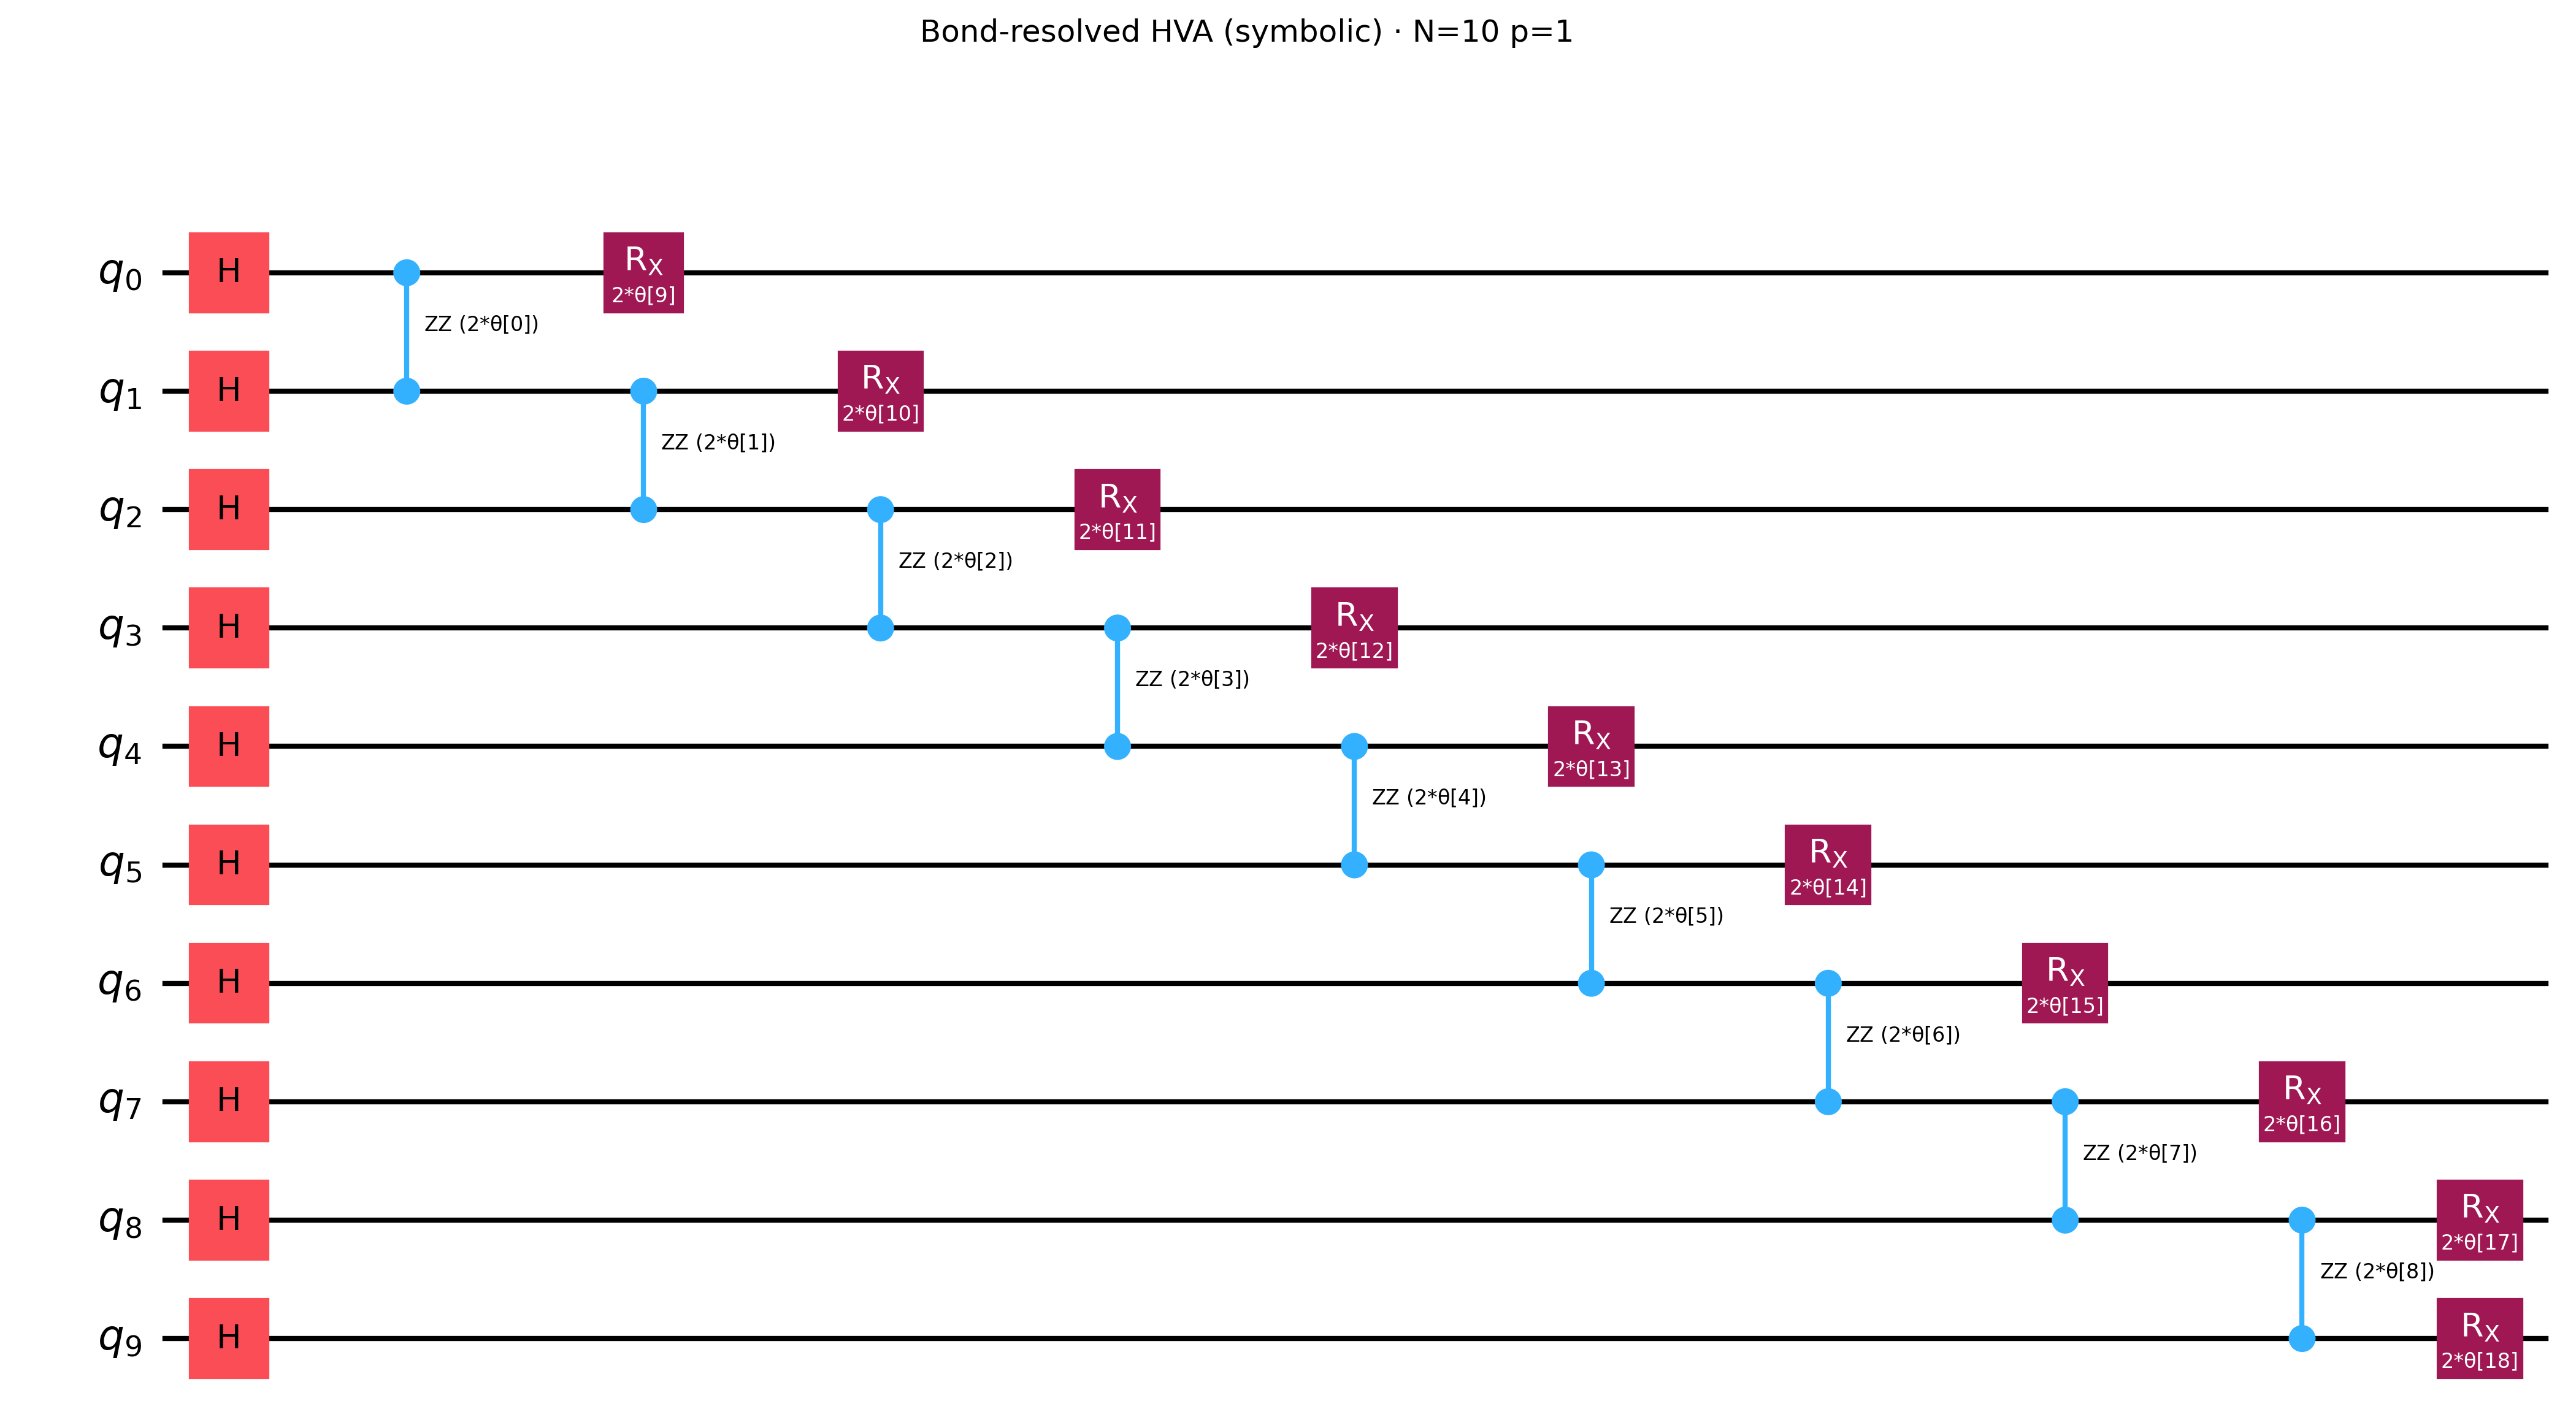

In [4]:
from qmbp_simulation.circuits.hva import HVACircuitBuilder
from qmbp_simulation.analysis.circuit_visualizer import save_circuit_diagram, circuit_summary

hva = HVACircuitBuilder()
qc, theta = hva.create_bond_resolved(cfg.n_qubits, cfg.p_layers, lattice)

print(f"num_qubits    = {qc.num_qubits}")
print(f"num_parameters= {qc.num_parameters}   (bond-resolved: {n_edges} θ_zz + {cfg.n_qubits} θ_x)")
summary = circuit_summary(qc)
for k in ("depth", "n_gates_total", "n_2q_gates", "n_1q_gates", "gate_counts"):
    print(f"  {k:14s}: {summary[k]}")

p = save_circuit_diagram(qc, FIG / "03_hva_ansatz.png",
                         title=f"Bond-resolved HVA (symbolic) · N={cfg.n_qubits} p={cfg.p_layers}")
show(p)

## 4. Ground truth clásico

`ClassicalSolver.solve(H, lattice)` da la energía exacta $E_0$, el gap espectral
y (para N chico) el ground state. Barremos todos los `h` para tener la referencia
contra la que compararemos VQE y GNN.


     h |           E0 |        gap | ground_state?
------------------------------------------------


  0.50 |     -9.76550 |    0.00146 | True


  1.00 |    -12.38149 |    0.29892 | True


  1.50 |    -16.53525 |    1.16724 | True


  2.00 |    -21.13932 |    2.13331 | True


  2.50 |    -25.90721 |    3.11840 | True


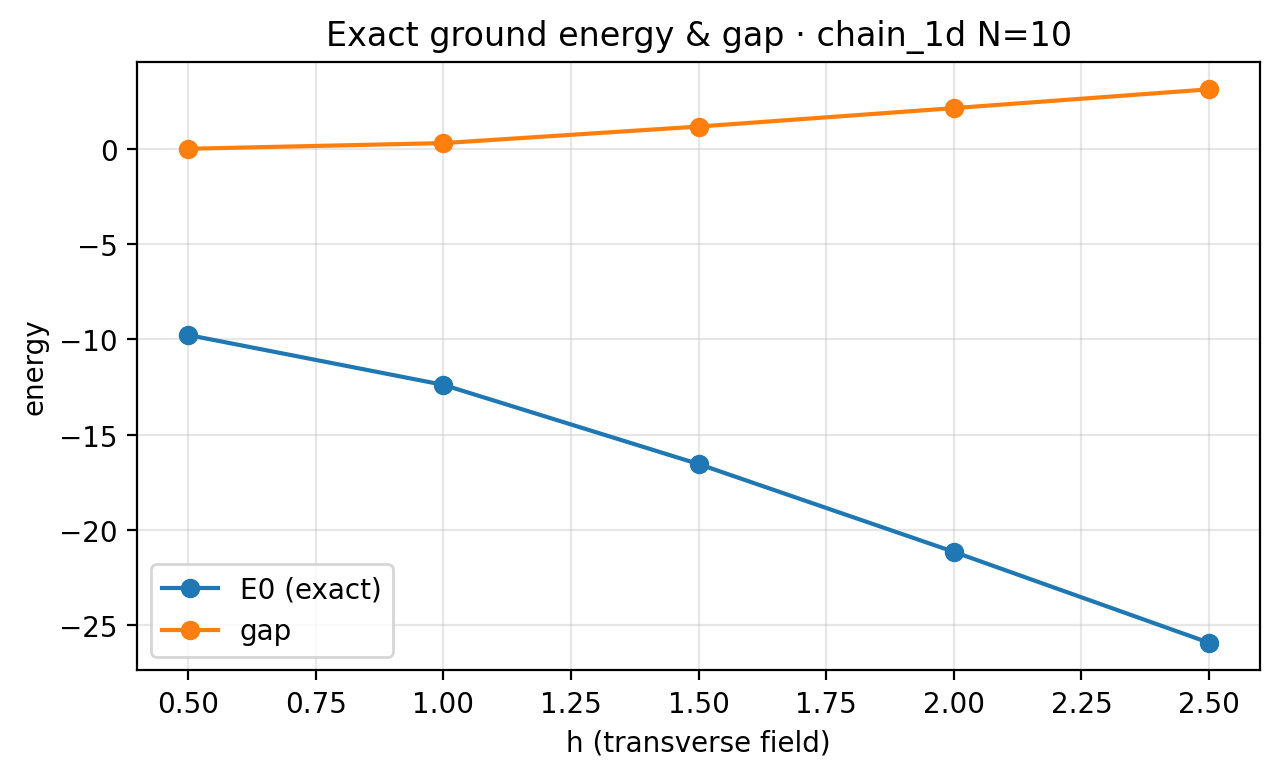

In [5]:
from qmbp_simulation.solvers import ClassicalSolver

solver = ClassicalSolver()
gt = {}
print(f"{'h':>6} | {'E0':>12} | {'gap':>10} | ground_state?")
print("-" * 48)
for h in cfg.h_values:
    lat_h = make_lattice(cfg.topology, cfg.n_qubits, J=cfg.j_coupling, h=h)
    H_h = builder.build(lat_h)
    res = solver.solve(H_h, lat_h)
    gt[h] = res
    print(f"{h:>6.2f} | {res.ground_energy:>12.5f} | {res.gap:>10.5f} | {res.ground_state is not None}")

p = save_line_plot(
    np.array(cfg.h_values),
    {"E0 (exact)": np.array([gt[h].ground_energy for h in cfg.h_values]),
     "gap": np.array([gt[h].gap for h in cfg.h_values])},
    FIG / "04_ground_truth.png",
    xlabel="h (transverse field)", ylabel="energy",
    title=f"Exact ground energy & gap · {cfg.topology} N={cfg.n_qubits}")
show(p)

## 5. VQE — llenar el ansatz con parámetros óptimos

`VQEOptimizer.optimize(H, circuit, initial_guess)` minimiza $\langle H\rangle$.
Warm-start descendente (reusamos el θ del h anterior), como en producción.
Mostramos el circuito **llenado** en el h de foco y las curvas E_VQE vs E0.


    [VQE] method=L-BFGS-B, maxiter=300, n_params=19, restarts=1


    [VQE] method=L-BFGS-B, maxiter=300, n_params=19, restarts=1


    [VQE] method=L-BFGS-B, maxiter=300, n_params=19, restarts=1


    [VQE] method=L-BFGS-B, maxiter=300, n_params=19, restarts=1


    [VQE] method=L-BFGS-B, maxiter=300, n_params=19, restarts=1


     h |        E_VQE |           E0 |      |dE| |  fidelity
------------------------------------------------------------
  0.50 |     -7.99024 |     -9.76550 |  1.78e+00 |    0.2083
  1.00 |    -11.90459 |    -12.38149 |  4.77e-01 |    0.7959
  1.50 |    -16.37546 |    -16.53525 |  1.60e-01 |    0.9640
  2.00 |    -21.06793 |    -21.13932 |  7.14e-02 |    0.9893
  2.50 |    -25.86954 |    -25.90721 |  3.77e-02 |    0.9957


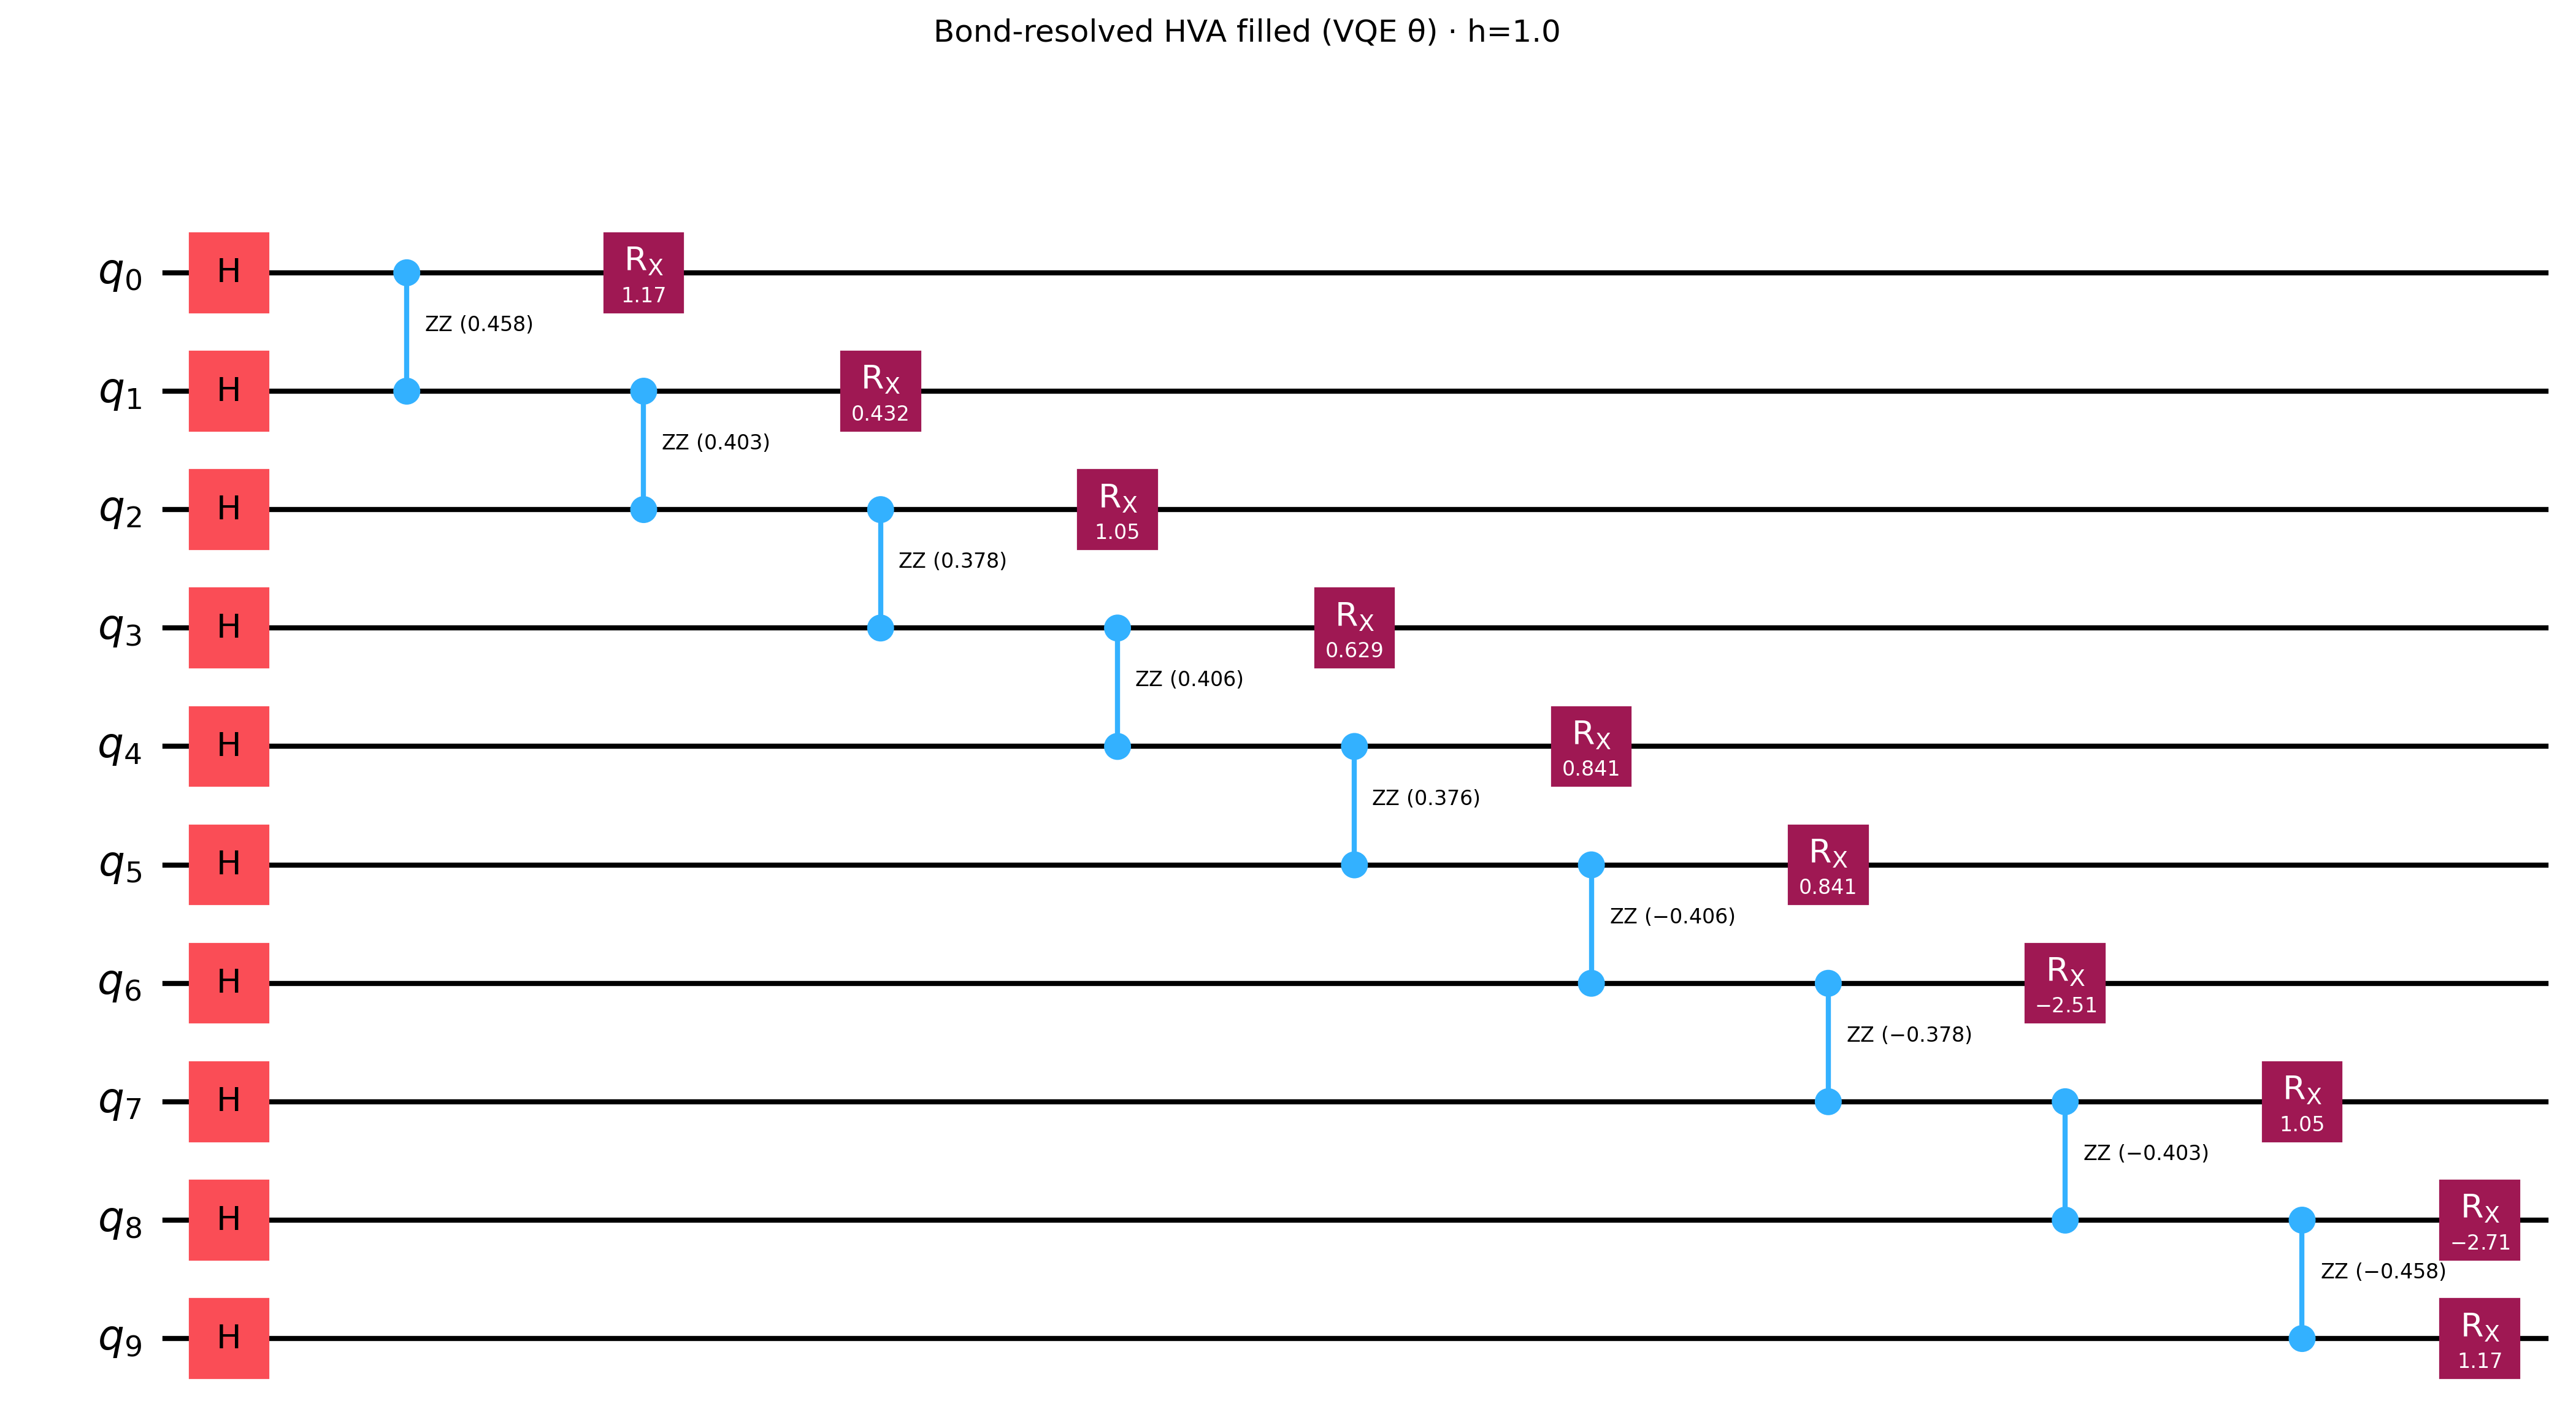

In [6]:
from qmbp_simulation.optimizers.vqe import VQEOptimizer
from qmbp_simulation import VQEConfig

vqe_cfg = VQEConfig(n_restarts=cfg.vqe_restarts, maxiter=cfg.vqe_maxiter)
optimizer = VQEOptimizer(config=vqe_cfg, seed=cfg.seed)

rng = np.random.default_rng(cfg.seed)
prev_theta = rng.uniform(-0.05, 0.05, n_params)

theta_by_h, e_vqe_by_h, fid_by_h = {}, {}, {}
for h in sorted(cfg.h_values, reverse=True):   # descending warm-start
    lat_h = make_lattice(cfg.topology, cfg.n_qubits, J=cfg.j_coupling, h=h)
    H_h = builder.build(lat_h)
    result = optimizer.optimize(H_h, qc, prev_theta.copy(),
                                exact_energy=gt[h].ground_energy,
                                exact_state=gt[h].ground_state)
    prev_theta = result.theta_opt.copy()
    theta_by_h[h] = result.theta_opt.copy()
    e_vqe_by_h[h] = result.energy
    fid_by_h[h] = result.fidelity

print(f"{'h':>6} | {'E_VQE':>12} | {'E0':>12} | {'|dE|':>9} | {'fidelity':>9}")
print("-" * 60)
for h in cfg.h_values:
    dE = abs(e_vqe_by_h[h] - gt[h].ground_energy)
    print(f"{h:>6.2f} | {e_vqe_by_h[h]:>12.5f} | {gt[h].ground_energy:>12.5f} | {dE:>9.2e} | {fid_by_h[h]:>9.4f}")

p = save_circuit_diagram(qc, FIG / "05_hva_filled.png", params=theta_by_h[cfg.h_focus],
                         title=f"Bond-resolved HVA filled (VQE θ) · h={cfg.h_focus}")
show(p)

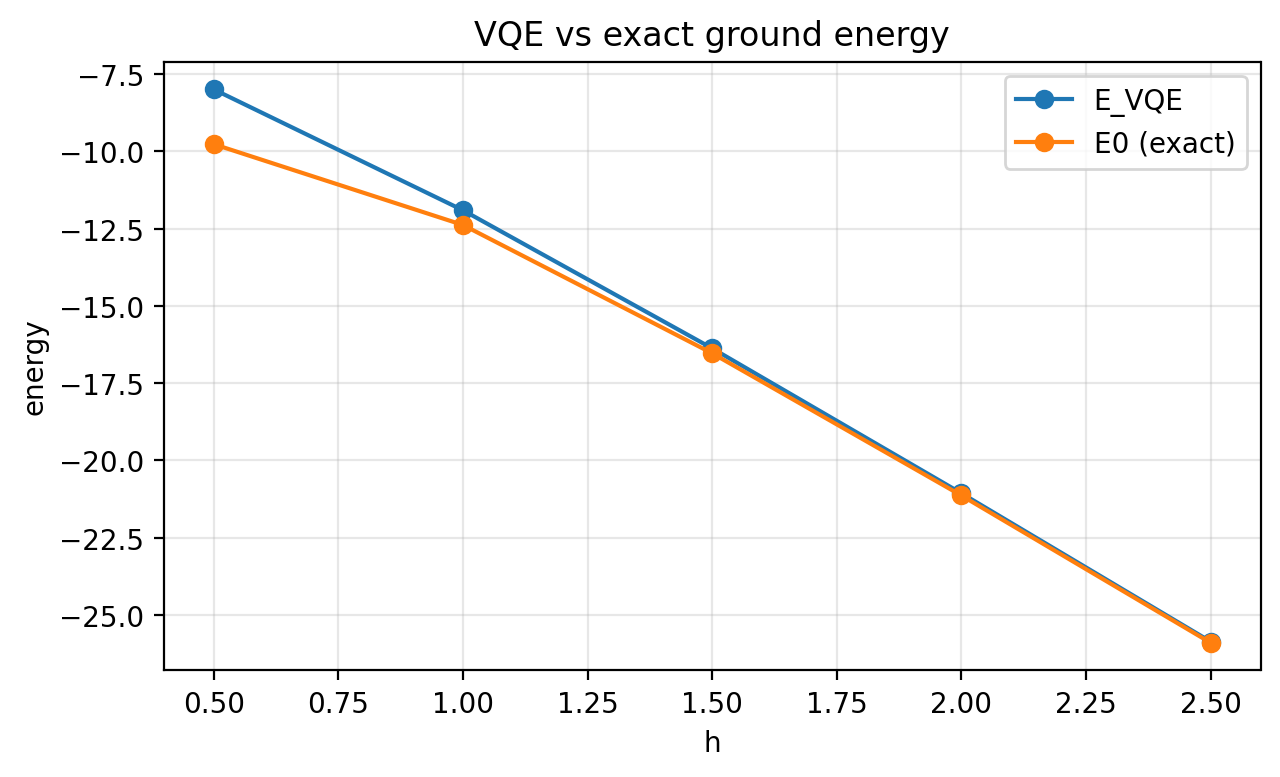

In [7]:
p = save_line_plot(
    np.array(cfg.h_values),
    {"E_VQE": np.array([e_vqe_by_h[h] for h in cfg.h_values]),
     "E0 (exact)": np.array([gt[h].ground_energy for h in cfg.h_values])},
    FIG / "05_energy_vqe_vs_exact.png",
    xlabel="h", ylabel="energy", title="VQE vs exact ground energy")
show(p)

### Cómo leer la tabla: por qué la fidelidad depende de $h$

Mirá la columna **fidelity**: es alta para $h$ grande (típicamente >0.95 en
$h\ge1.5$) y **cae fuerte cerca de $h_c=1$** (a menudo <0.3 en $h=0.5$). Esto no
es un fallo del optimizador — es una consecuencia directa del ansatz de la fase 3.

- **$h \gg h_c$ (fase paramagnética):** el ground state está *cerca* de
  $|+\rangle^{\otimes N}$, que es justo donde arranca el circuito. Poco
  entrelazamiento, correcciones pequeñas → **una sola capa $p=1$ alcanza** y la
  fidelidad es casi 1.

- **$h \approx h_c$ (punto crítico):** aquí el ground state tiene **entrelazamiento
  máximo** (correlaciones de largo alcance, la entropía de entrelazamiento crece
  con el tamaño). Un ansatz de profundidad $p=1$ solo puede generar
  entrelazamiento de corto alcance (una capa de $R_{ZZ}$) → **es estructuralmente
  incapaz** de representar el estado crítico, y la fidelidad cae.

- **$h \ll h_c$ (fase ferromagnética/ordenada):** el ground state es una
  superposición tipo GHZ ($|00\dots0\rangle+|11\dots1\rangle$), también muy
  entrelazada y lejana a $|+\rangle^{\otimes N}$ → $p=1$ tampoco alcanza.

La **energía** es más indulgente que la fidelidad: por el principio variacional
$E_{VQE}\ge E_0$, y $\langle H\rangle$ puede quedar razonablemente cerca de $E_0$
aunque el *estado* no lo esté (dos estados distintos pueden tener energías
parecidas). Por eso $|dE|$ se ve chico mientras la fidelidad ya bajó: **la
fidelidad es el diagnóstico honesto de qué tan bien el ansatz captura el estado.**

Conclusión didáctica: la limitación es del **número de capas**, no del método.
Subir $p$ agregaría capacidad de entrelazamiento y subiría la fidelidad cerca de
$h_c$ (esa comparación queda para una extensión futura).


## 5b. Circuito transpilado a gates nativos (fase B)

### Qué es un *basis gate set* nativo y por qué se necesita

El circuito de la fase 3 usa compuertas "lógicas" ($R_{ZZ}$, $R_X$, $H$) que son
convenientes para razonar, pero **el hardware no las ejecuta directamente**. Cada
procesador físico implementa solo un puñado de compuertas calibradas — su
*basis gate set*. Para un dispositivo IBM tipo Heron usamos `cz, rz, sx, x`.
**Transpilar** es reescribir el circuito lógico como una secuencia equivalente
que solo usa esas compuertas nativas (y, en hardware real, respetando la
conectividad física). Sin este paso, el circuito no es ejecutable.

### Por qué la profundidad crece

Cada compuerta lógica se descompone en varias nativas. La descomposición clave
aquí es la del acoplamiento:

$$R_{ZZ}(\phi) \;=\; \text{CZ}\;\cdot\;\big(R_Z(\phi)\ \text{en un qubit}\big)\;\cdot\;\text{CZ}$$

es decir, **cada $R_{ZZ}$ se convierte en 2 CZ** (más rotaciones de 1 qubit
entremedio). Por eso vas a ver el conteo de gates de 2 qubits **duplicarse**:
9 $R_{ZZ}$ lógicos → 18 CZ nativos. Las Hadamard y $R_X$ también se reexpresan en
`sx`/`rz`/`x`, lo que infla el conteo de 1 qubit y la profundidad total.

### Por qué la 2Q-depth es el predictor de error dominante

En hardware NISQ, las **compuertas de 2 qubits (CZ) son las más ruidosas** — su
error típico es ~10× el de una compuerta de 1 qubit. Por eso la métrica que mejor
anticipa la degradación en hardware no es la profundidad total, sino la
**profundidad de 2 qubits** (`depth_2q`): cuántas capas de CZ atraviesa el
camino crítico. Menos 2Q-depth → menos exposición al ruido dominante → mejor
fidelidad en el dispositivo real. Es la métrica que miramos al decidir si un
circuito es viable en hardware.

`transpiled_circuit_stats` reporta profundidad total, `depth_2q`, `n_2q_gates` y
el breakdown por tipo. Comparamos lógico vs nativo abajo.


basis_gates = ['cz', 'rz', 'sx', 'x']   optimization_level = 3

metric                 |    logical |   native (ISA)
----------------------------------------------------
depth (total)          |         11 |             72
depth_2q               |          - |             18
2-qubit gates          |          9 |             18
1-qubit gates          |         20 |            139
total gates            |         29 |            157

native gate breakdown (count_ops): {'rz': 65, 'sx': 65, 'cz': 18, 'x': 9}
parallelism_ratio: 1.0


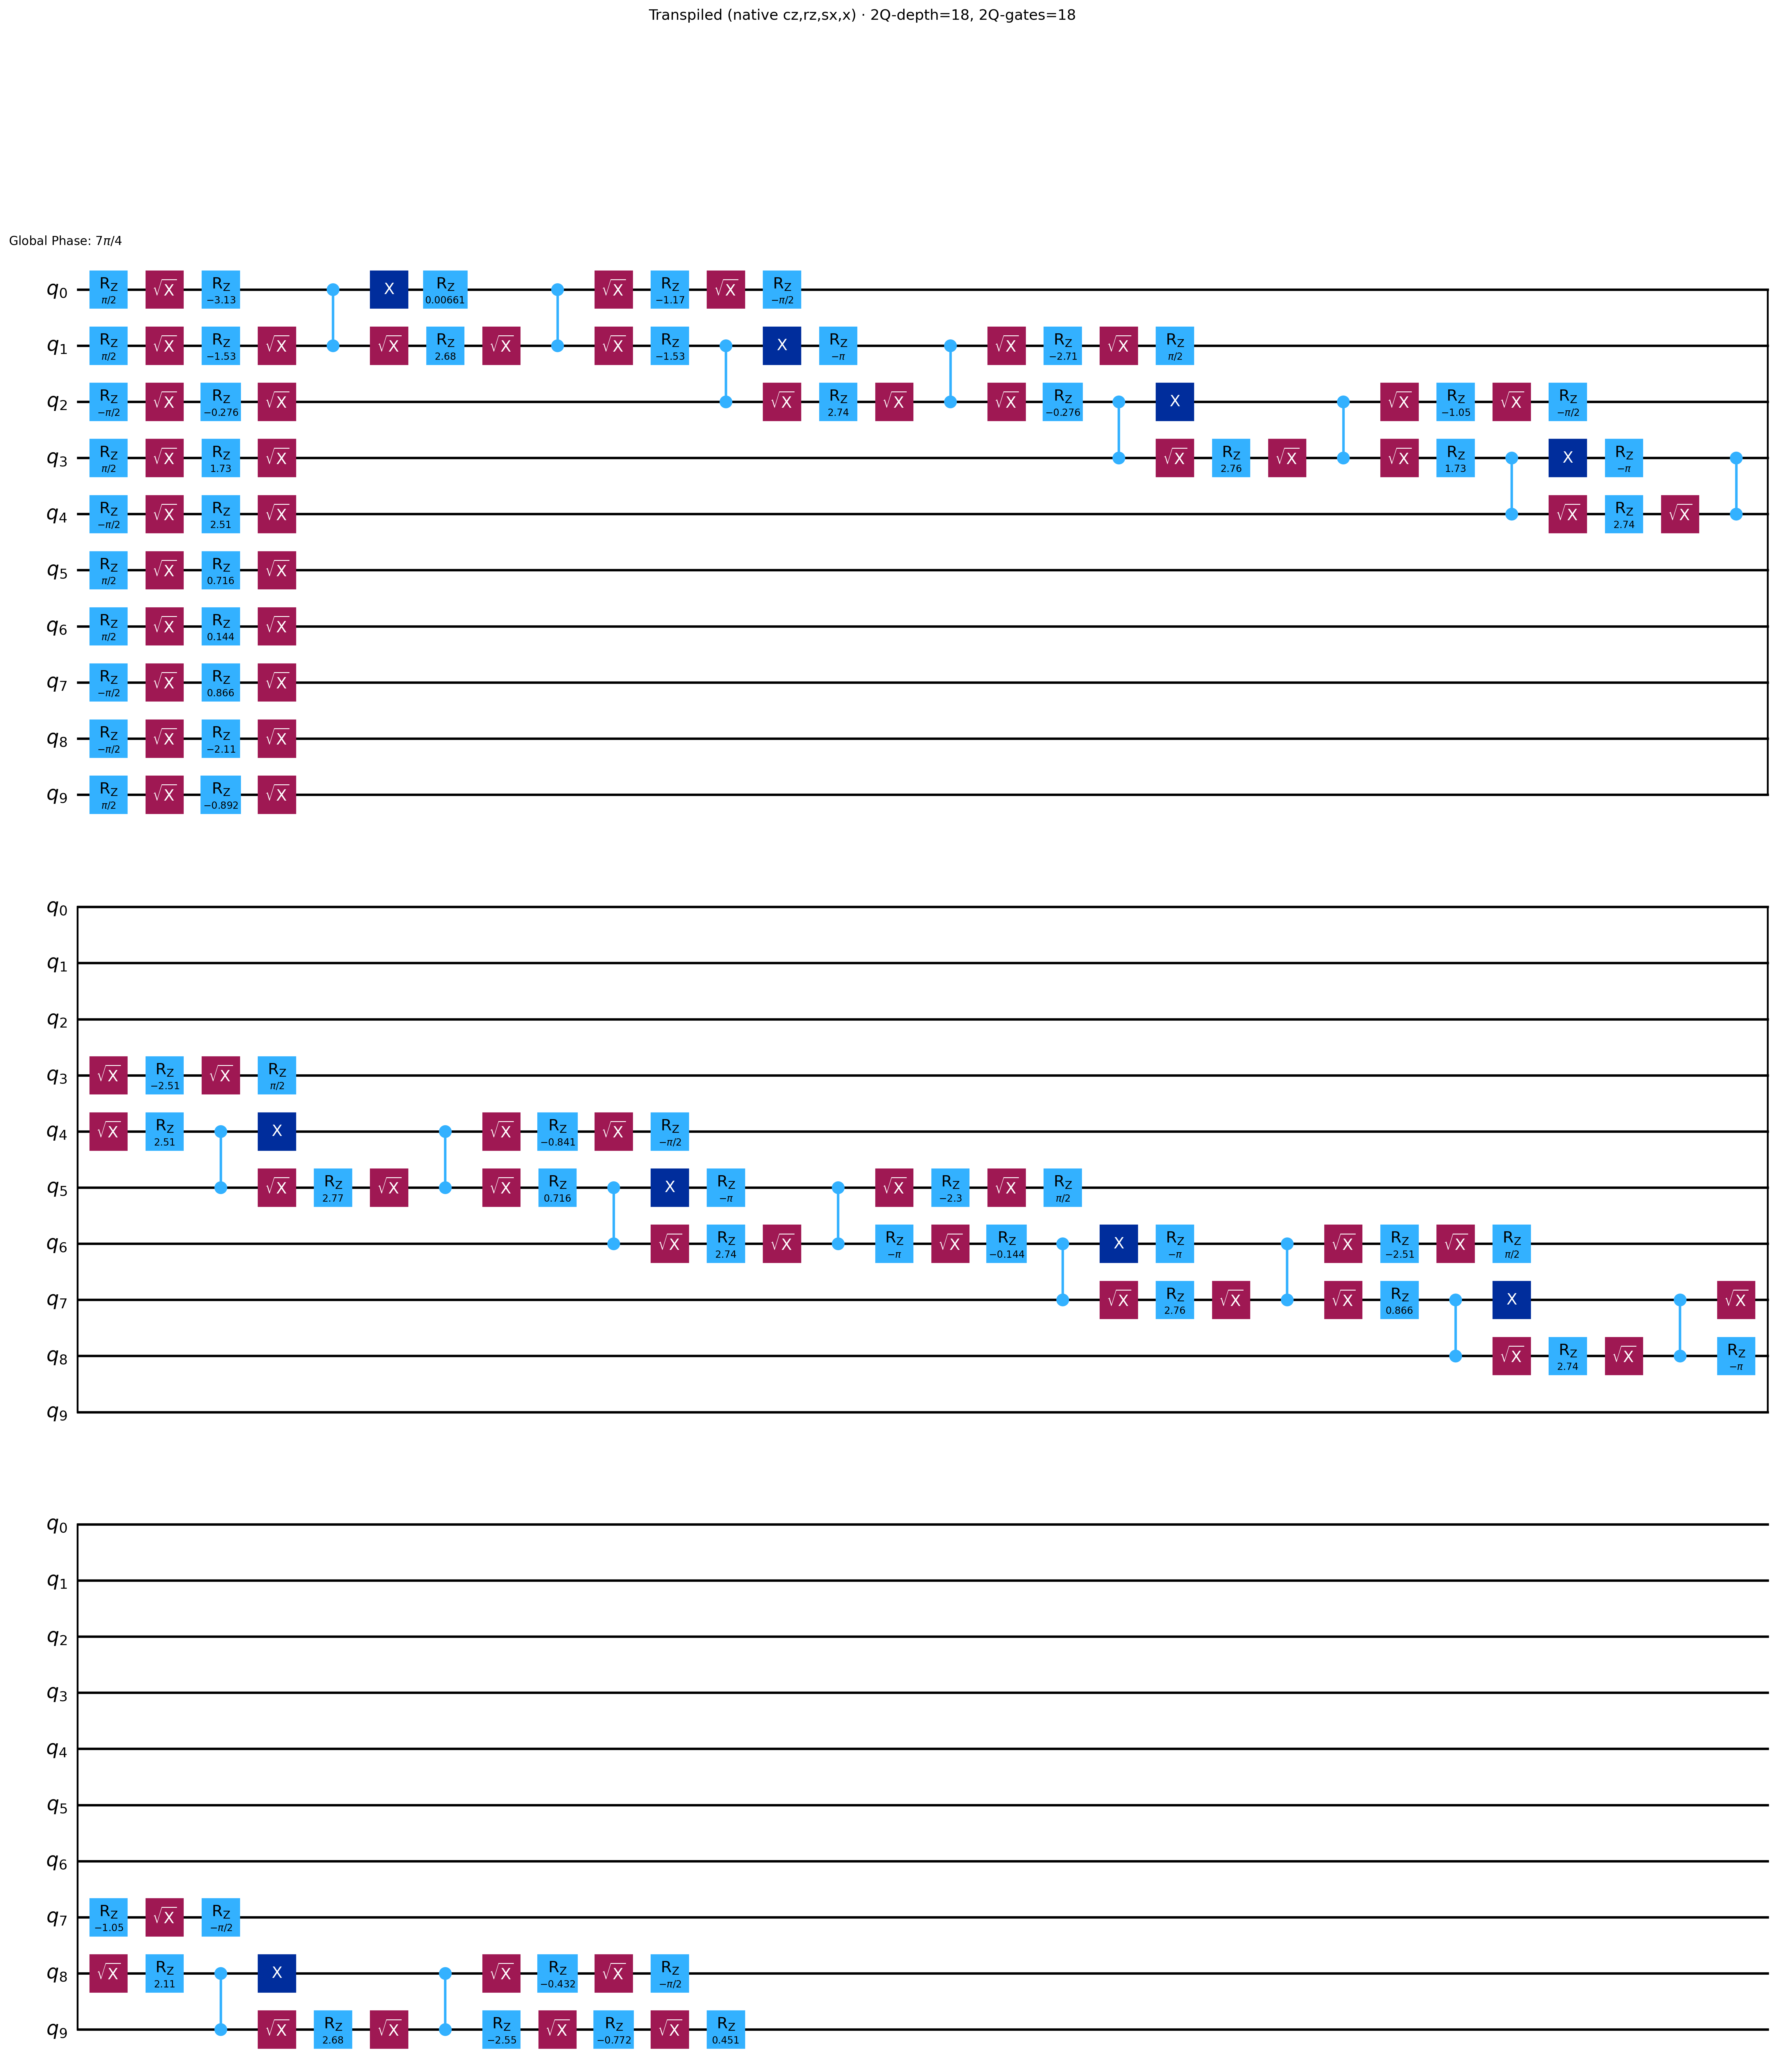

In [8]:
from qiskit import transpile
from qmbp_simulation.analysis.circuit_visualizer import transpiled_circuit_stats

# Bind the focus-h VQE angles so the transpiled circuit is a concrete (ISA) circuit.
bound = qc.assign_parameters(theta_by_h[cfg.h_focus])
tqc = transpile(bound, basis_gates=list(cfg.basis_gates),
                optimization_level=cfg.opt_level, seed_transpiler=cfg.seed)

logical = circuit_summary(bound)
native = transpiled_circuit_stats(tqc)

print(f"basis_gates = {list(cfg.basis_gates)}   optimization_level = {cfg.opt_level}\n")
print(f"{'metric':<22} | {'logical':>10} | {'native (ISA)':>14}")
print("-" * 52)
print(f"{'depth (total)':<22} | {logical['depth']:>10} | {native['depth']:>14}")
print(f"{'depth_2q':<22} | {'-':>10} | {native['depth_2q']:>14}")
print(f"{'2-qubit gates':<22} | {logical['n_2q_gates']:>10} | {native['n_2q_gates']:>14}")
print(f"{'1-qubit gates':<22} | {logical['n_1q_gates']:>10} | {native['n_1q_gates']:>14}")
print(f"{'total gates':<22} | {logical['n_gates_total']:>10} | {native['total_gates']:>14}")
print(f"\nnative gate breakdown (count_ops): {native['count_ops']}")
print(f"parallelism_ratio: {native.get('parallelism_ratio')}")

p = save_circuit_diagram(tqc, FIG / "05b_transpiled.png",
                         title=f"Transpiled (native {','.join(cfg.basis_gates)}) · "
                               f"2Q-depth={native['depth_2q']}, 2Q-gates={native['n_2q_gates']}")
show(p)

## 6. Auto-selección del modelo del zoo (fase A)

En vez de entrenar, dejamos que el proyecto **elija el mejor modelo pre-entrenado**
para nuestro objetivo con `select_model_for_objective`. Devuelve el modelo cargado,
la entrada del zoo, y — clave — un **reporte de confianza** con la base estadística
y warnings. Esto es transparente sobre *cuánto* confiar en la predicción.

Objetivos posibles: `deploy` (fidelidad en régimen paramagnético), `warmstart`
(ventaja sobre cold-start), `critical` (física cerca de h_c), `extrapolation`
(N grande). Usamos `cfg.zoo_objective`.


In [9]:
from qmbp_simulation.predictors.model_zoo import select_model_for_objective

sel = select_model_for_objective(
    cfg.topology,
    objective=cfg.zoo_objective,
    model=cfg.zoo_model,
    p_layers=cfg.p_layers,
    n_target=cfg.n_qubits,
)
model = sel["model"]
entry = sel["entry"]

print(f"objective         : {sel['objective']}")
print(f"selected checkpoint: {entry.checkpoint_file}")
print(f"source            : {sel['source']}  (per_topology | multi_topology | single_n)")
print(f"confidence        : {sel['confidence']:.2%}  [{sel['confidence_basis']}]")
print(f"reliable          : {sel['reliable']}")
print(f"model arch        : node_features={model.node_features}, hidden={model.hidden_dim}, "
      f"layers={model.n_layers}, params={sum(p.numel() for p in model.parameters())}")
if sel["warnings"]:
    print("\nwarnings:")
    for w in sel["warnings"]:
        print(f"  ⚠️  {w}")

objective         : critical
selected checkpoint: unifMPNN__chain_1d_p1_h_0p5_1p5.pt
source            : per_topology  (per_topology | multi_topology | single_n)
confidence        : 15.56%  [global_pass_rate_discounted]
reliable          : True
model arch        : node_features=5, hidden=256, layers=3, params=402321

warnings:
  ⚠️  Confidence derived from GLOBAL pass_rate (not target-specific). Treat as a rough lower bound.


## 7. El grafo unificado que consume el GNN

### Por qué un grafo *heterogéneo*

Un MPNN predice una cantidad *por nodo*. Pero nuestro ansatz bond-resolved tiene
dos tipos de parámetros con roles distintos: un $\theta_{zz}$ por **bond** y un
$\theta_x$ por **sitio**. Si el grafo tuviera solo nodos de qubit, no habría un
lugar natural donde "colgar" el $\theta_{zz}$ de cada bond. La solución (estilo
Qracle) es un **grafo heterogéneo** que representa explícitamente tanto el
Hamiltoniano como la estructura del circuito, con varios tipos de nodo:

- **nodos qubit** (type 0): un por qubit; sus features incluyen $h$, el número de
  coordinación y el color bipartito del sitio.
- **nodos ZZ-gate** (type 1): uno por cada bond × capa; representan una compuerta
  $R_{ZZ}$ del circuito. Están conectados a los dos qubits sobre los que actúan.
- **nodos RX-gate** (type 2): uno por cada sitio × capa; representan un $R_X$.
- **nodo global** (type 3): conectado a todos los qubits, propaga información de
  contexto de todo el sistema (útil para cross-N).

Las aristas codifican tanto la conectividad física (qubit↔qubit) como el flujo
del circuito (gate↔qubit, y orden causal ZZ→RX entre capas).

### Cómo el GNN lee los parámetros de los nodos correctos

Tras varias rondas de *message passing* (cada nodo agrega información de sus
vecinos), el `UnifiedMPNN` hace un **readout por tipo de nodo**:

- $\theta_{zz}^{(k)}$ se lee del embedding del **nodo ZZ-gate** $k$ — ese nodo
  aprendió a representar el ángulo de su bond agregando información de los dos
  qubits que conecta.
- $\theta_x^{(i)}$ se lee del embedding del **nodo qubit** (o RX-gate) $i$.

Así, la heterogeneidad del grafo se mapea 1-a-1 con la estructura bond-resolved
del ansatz: cada parámetro sale del nodo que lo representa. Abajo dibujamos el
grafo coloreado por tipo (para N=10 p=1: 10 qubit + 9 ZZ + 10 RX + 1 global).

### De vuelta al principio: el nodo ZZ *es* el término $-J\,ZZ$

Cerremos el círculo que abrimos en la fase 3. Cada **nodo ZZ-gate** de este grafo
no es una entidad nueva — es la misma cadena que venimos siguiendo, un eslabón más:

$$\underbrace{-J\,Z_iZ_j}_{\text{término de }H\ \text{(fase 2)}}
\;\longrightarrow\;
\underbrace{R_{ZZ}(2\theta_{zz})\ \text{en el bond }(i,j)}_{\text{compuerta del ansatz (fase 3)}}
\;\longrightarrow\;
\underbrace{\text{nodo ZZ-gate}}_{\text{este grafo (fase 7)}}
\;\longrightarrow\;
\underbrace{\theta_{zz}^{(k)}}_{\text{predicción (fase 8)}}$$

Y en paralelo, la otra rama: $-h\,X_i \to R_X(2\theta_x) \to$ nodo qubit $\to
\theta_x^{(i)}$. Por eso el grafo tiene **exactamente** 9 nodos ZZ (uno por bond,
= los 9 términos $ZZ$ del Hamiltoniano) y 10 nodos qubit (uno por sitio, = los 10
términos $X$): el grafo es una **transcripción** de $H$ y del circuito, no una
estructura aparte. Cuando en la fase 8 la red emita 19 números, cada uno saldrá
del nodo que corresponde a su término original en $H$.


total nodes   : 30
features/node : 5
edges (directed): 112
n_edges_unique (bonds): 9
node types    :
  qubit     : 10
  ZZ gate   : 9
  RX gate   : 10
  global    : 1


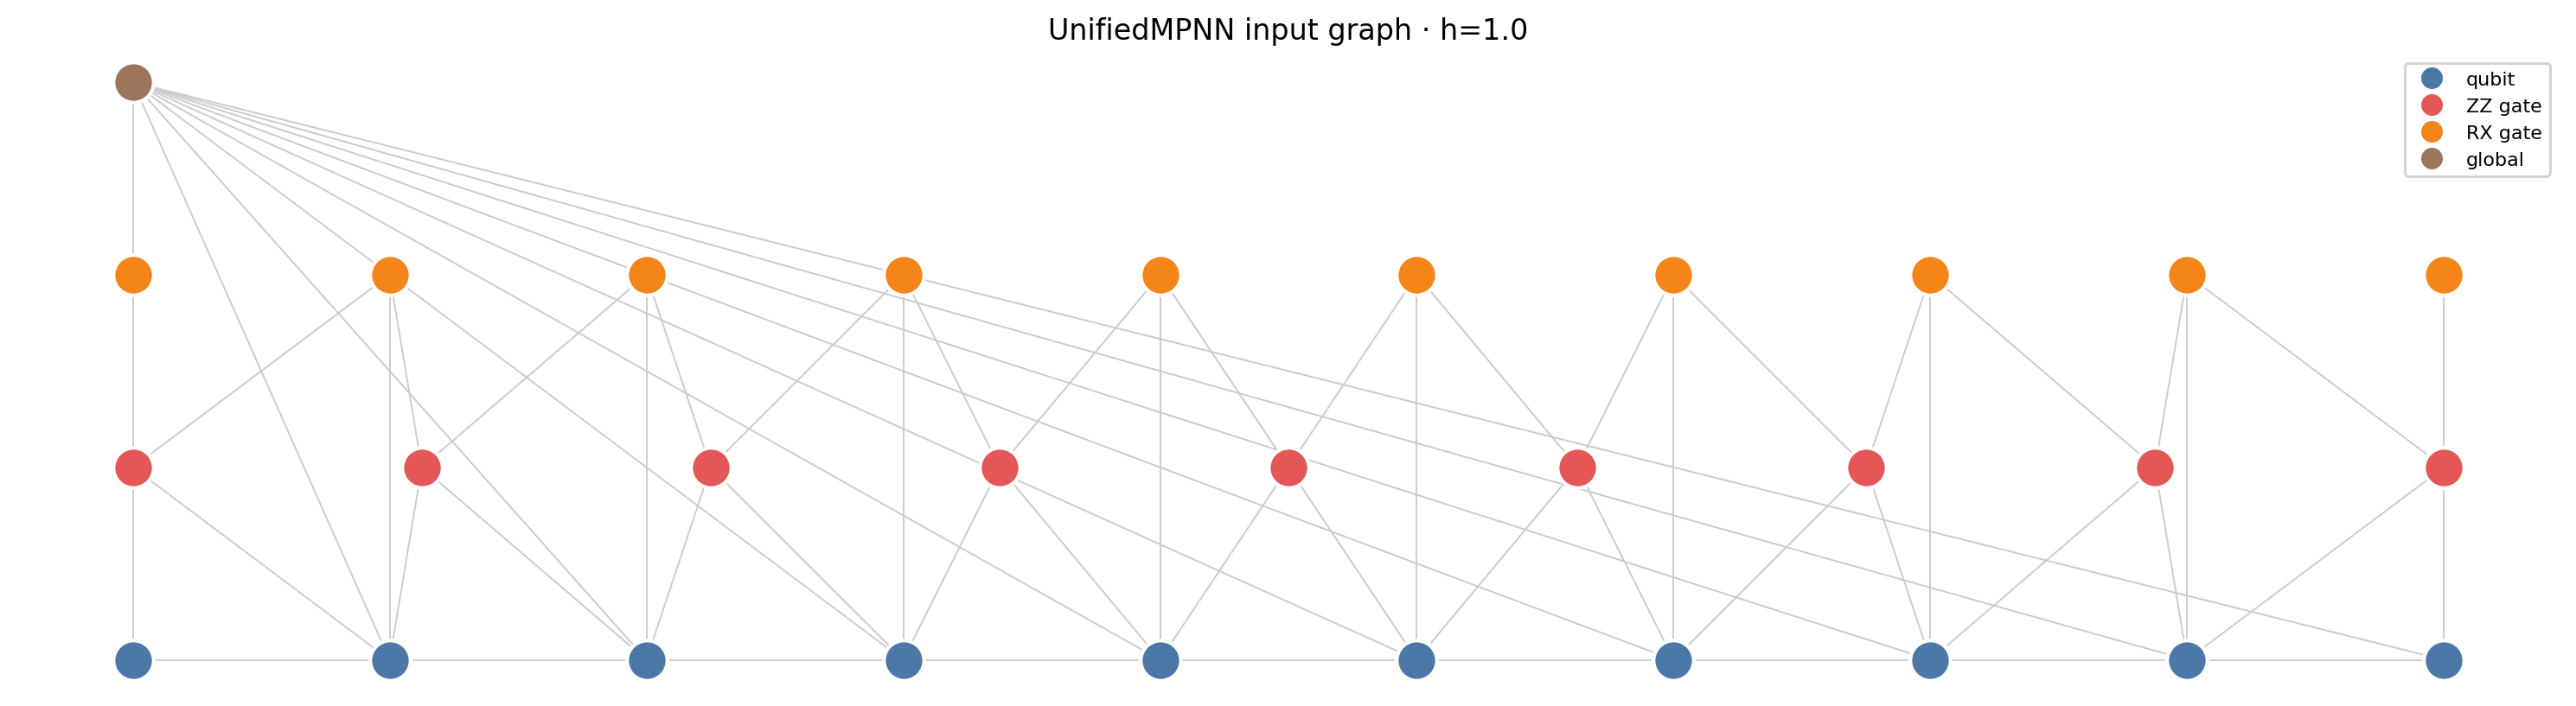

In [10]:
from qmbp_simulation.predictors.unified_graph import build_graph_for_model

g_focus = build_graph_for_model(model, lattice, h_value=cfg.h_focus, p_layers=cfg.p_layers)
import collections
type_names = {0: "qubit", 1: "ZZ gate", 2: "RX gate", 3: "global", 4: "RZ gate"}
counts = collections.Counter(g_focus.node_type.tolist())
print(f"total nodes   : {g_focus.x.shape[0]}")
print(f"features/node : {g_focus.x.shape[1]}")
print(f"edges (directed): {g_focus.edge_index.shape[1]}")
print(f"n_edges_unique (bonds): {g_focus.n_edges_unique}")
print("node types    :")
for t, c in sorted(counts.items()):
    print(f"  {type_names.get(t, t):10s}: {c}")

p = draw_mpnn_graph(g_focus, FIG / "07_unified_graph.png",
                    title=f"UnifiedMPNN input graph · h={cfg.h_focus}")
show(p)

## 8. Predicción del GNN vs VQE

Un *forward pass* del `UnifiedMPNN` sobre el grafo de cada $h$ produce los θ
predichos (bond-resolved) — **sin optimizar nada**: es el mapeo directo
grafo→ángulos que la red aprendió. Los comparamos contra los θ que el VQE
encontró optimizando (fase 5), que actúan como "verdad de referencia".

### Cómo leer el scatter

Cada punto es un parámetro: eje $x$ = valor del VQE (target), eje $y$ = valor
predicho por el GNN. La línea diagonal es la predicción perfecta.

- **Puntos sobre la diagonal** → el GNN reprodujo ese ángulo casi exacto: aprendió
  bien esa parte del mapeo.
- **Dispersión alrededor de la diagonal** → error de predicción. Cuanto más lejos
  de la línea, mayor el desvío en ese parámetro.

### Por qué puede desviarse

- **Régimen fuera de lo aprendido:** el modelo del zoo fue entrenado en un rango
  de $h$ acotado (recordá el reporte de confianza de la fase 6). En $h$ lejos de
  ese rango, extrapola y se desvía más.
- **Puntos difíciles (cerca de $h_c$):** ahí el propio target del VQE es poco
  fiable (fidelidad baja, fase 5), así que "acertarle" al VQE no siempre es
  deseable — el objetivo real es la energía, que evaluamos en la fase 9.
- **Simetría $\mathbb{Z}_2$ del TFIM:** $(\theta_{zz},\theta_x)$ y
  $(-\theta_{zz},-\theta_x)$ dan el mismo estado físico. Un ángulo predicho con
  signo opuesto al del VQE puede ser igualmente válido y aun así aparecer lejos
  de la diagonal. Por eso el scatter es una guía cualitativa; **la métrica que
  decide es la energía resultante** (fase 9).


     h |  ||θ_vqe|| |  ||θ_pred|| |    ||Δθ||
----------------------------------------------
  0.50 |     2.7221 |      1.1978 |    2.8309
  1.00 |     2.3504 |      1.1883 |    2.4996
  1.50 |     2.1770 |      1.1893 |    2.3534
  2.00 |     2.1046 |      1.1903 |    2.2947
  2.50 |     2.0695 |      1.1914 |    2.2673


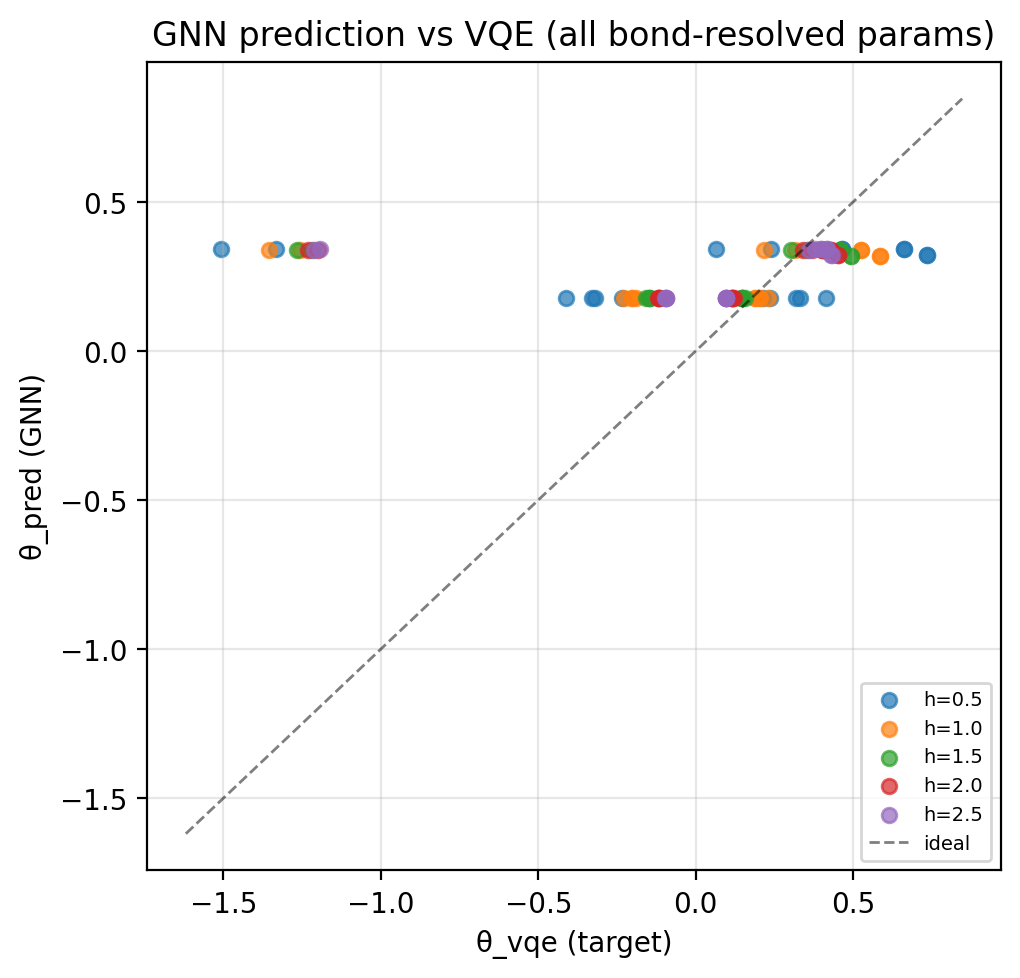

In [11]:
import torch

model.eval()
theta_pred = {}
with torch.no_grad():
    for h in cfg.h_values:
        g_h = build_graph_for_model(model, lattice, h_value=h, p_layers=cfg.p_layers)
        theta_pred[h] = model(g_h).numpy().flatten()

print(f"{'h':>6} | {'||θ_vqe||':>10} | {'||θ_pred||':>11} | {'||Δθ||':>9}")
print("-" * 46)
for h in cfg.h_values:
    dtheta = np.linalg.norm(theta_pred[h] - theta_by_h[h])
    print(f"{h:>6.2f} | {np.linalg.norm(theta_by_h[h]):>10.4f} | "
          f"{np.linalg.norm(theta_pred[h]):>11.4f} | {dtheta:>9.4f}")

import matplotlib
matplotlib.use("Agg")
fig, ax = plt.subplots(figsize=(5.2, 5.0))
for h in cfg.h_values:
    ax.scatter(theta_by_h[h], theta_pred[h], s=28, alpha=0.7, label=f"h={h}")
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="ideal")
ax.set_xlabel("θ_vqe (target)"); ax.set_ylabel("θ_pred (GNN)")
ax.set_title("GNN prediction vs VQE (all bond-resolved params)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(str(FIG / "08_theta_pred_vs_vqe.png"), dpi=200, bbox_inches="tight"); plt.close(fig)
show(FIG / "08_theta_pred_vs_vqe.png")

## 9. Cierre del loop — energía con θ del GNN

Evaluamos $\langle H\rangle$ usando directamente los θ predichos por el GNN (sin
optimizar) y lo comparamos con $E_0$ y con el VQE. Muestra la calidad del modelo
del zoo como predictor/warm-start end-to-end.


     h |        E_GNN |        E_VQE |           E0 |  |dE|/gap
--------------------------------------------------------------
  0.50 |     -7.35468 |     -7.99024 |     -9.76550 |  1.65e+03
  1.00 |    -11.79113 |    -11.90459 |    -12.38149 |  1.97e+00
  1.50 |    -16.24126 |    -16.37546 |    -16.53525 |  2.52e-01
  2.00 |    -20.69048 |    -21.06793 |    -21.13932 |  2.10e-01
  2.50 |    -25.13878 |    -25.86954 |    -25.90721 |  2.46e-01


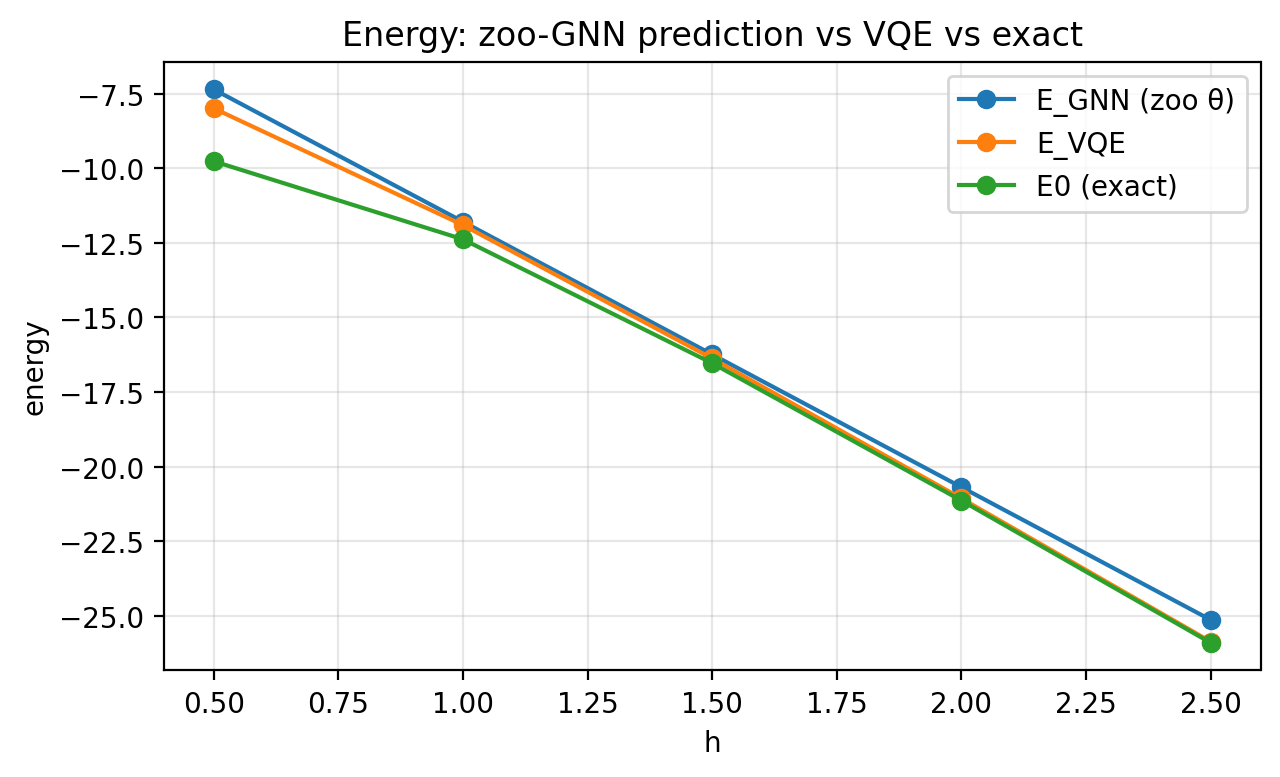

In [12]:
from qmbp_simulation.execution import NoiselessBackend

backend = NoiselessBackend()
e_gnn = {}
print(f"{'h':>6} | {'E_GNN':>12} | {'E_VQE':>12} | {'E0':>12} | {'|dE|/gap':>9}")
print("-" * 62)
for h in cfg.h_values:
    lat_h = make_lattice(cfg.topology, cfg.n_qubits, J=cfg.j_coupling, h=h)
    H_h = builder.build(lat_h)
    e = backend.evaluate(qc, H_h, theta_pred[h])
    e_gnn[h] = e
    dE_gap = abs(e - gt[h].ground_energy) / gt[h].gap
    print(f"{h:>6.2f} | {e:>12.5f} | {e_vqe_by_h[h]:>12.5f} | {gt[h].ground_energy:>12.5f} | {dE_gap:>9.2e}")

p = save_line_plot(
    np.array(cfg.h_values),
    {"E_GNN (zoo θ)": np.array([e_gnn[h] for h in cfg.h_values]),
     "E_VQE": np.array([e_vqe_by_h[h] for h in cfg.h_values]),
     "E0 (exact)": np.array([gt[h].ground_energy for h in cfg.h_values])},
    FIG / "09_energy_gnn_vs_all.png",
    xlabel="h", ylabel="energy", title="Energy: zoo-GNN prediction vs VQE vs exact")
show(p)

## 10. Resumen

Recorrido completo, fase por fase:

1. **Lattice** → topología / grafo físico
2. **Hamiltoniano** → `SparsePauliOp`
3. **Ansatz HVA bond-resolved** → 19 params (9 bonds + 10 sitios) para N=10 p=1
4. **Ground truth** → E₀, gap
5. **VQE** → θ óptimos, circuito llenado
5b. **Transpilado** → gates nativos, 2Q-depth y conteo de compuertas 2Q
6. **Auto-selección del zoo** → mejor modelo pre-entrenado + reporte de confianza
7. **Grafo unificado** → nodos qubit + compuerta que consume el `UnifiedMPNN`
8. **Predicción** → θ_pred vs θ_vqe
9. **Cierre del loop** → energía con θ del GNN vs exacto

Todas las figuras quedaron en `notebooks/gnn_hva_pipeline_anatomy/figures/`.

**Para experimentar:** cambiá un campo de `PipelineConfig` (celda 0) — por ejemplo
`n_qubits`, `h_values`, `zoo_objective` (`deploy`/`warmstart`/`critical`),
`basis_gates`, `opt_level` — y volvé a ejecutar. Cada fase es independiente y
reutiliza los módulos de producción.


In [13]:
import os
print("Figuras generadas:")
for f in sorted(os.listdir(FIG)):
    if f.endswith(".png") and not f.startswith("_"):
        print(f"  {FIG / f}")

Figuras generadas:
  /Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatomy/figures/01_lattice.png
  /Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatomy/figures/02_hamiltonian_matrix.png
  /Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatomy/figures/03_hva_ansatz.png
  /Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatomy/figures/04_ground_truth.png
  /Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatomy/figures/05_energy_vqe_vs_exact.png
  /Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatomy/figures/05_hva_filled.png
  /Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatomy/figures/05b_transpiled.png
  /Users/franco.raineri/devTools/QuantumDev/qmbp_gnn_adapt-vqe/notebooks/gnn_hva_pipeline_anatom